## Build the Global Dataset
We begin by building the dataset based on desired data from the 10 locations that we've determined as those with sufficient data quality.

The data will be stored locally for now, intending to move this to AWS S3 in the future.

In [1]:
import os

os.makedirs("data/raw", exist_ok=True)

### Retrieve Locally Stored Data
Each location has its own Jupyter notebook (in `location-test-data/usable` folder) where the WQP API was called for that location's bounding box, the measurements data was fetched, and the data quality was evaluated for different characteristics. The resulting dataframe created was stored in `data/raw` with corresponding names of the locations.

We create a single data frame by retrieving the measurements data for different locations and concatting it together.

In [2]:
import pandas as pd

files = {
    "riverview": "data/raw/riverview.csv",
    "houston_buffalo_bayou": "data/raw/houston.csv",
    "des_moines": "data/raw/des_moines.csv",
    "sacramento": "data/raw/sacramento.csv",
    "baton_rouge": "data/raw/baton_rouge.csv",
    "kansas_city": "data/raw/kansas_city.csv",
    "memphis": "data/raw/memphis.csv",
    "toledo": "data/raw/toledo.csv",
    "st_louis": "data/raw/st_louis.csv",
    "columbus": "data/raw/columbus.csv",
}

dfs = []

for location, path in files.items():
    df = pd.read_csv(path, low_memory=False)
    df["location"] = location
    dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

print("Data shape (rows, columns) of raw data:", raw_df.shape)
raw_df.head()

Data shape (rows, columns) of raw data: (537157, 19)


,ActivityStartDate,ActivityStartTime/Time,ActivityEndDate,ActivityEndTime/Time,MonitoringLocationIdentifier,ActivityDepthHeightMeasure/MeasureValue,ActivityMediaName,CharacteristicName,ResultMeasureValue,ResultMeasure/MeasureUnitCode,ResultStatusIdentifier,MeasureQualifierCode,DetectionQuantitationLimitMeasure/MeasureValue,ResultDetectionConditionText,ProjectIdentifier,ResultAnalyticalMethod/MethodName,ProviderName,ActivityDepthHeightMeasure/MeasureUnitCode,location
0,2016-06-08,08:38:01,NaN,NaN,21FLTBW_WQX-AR510461,0.2,Water,Salinity,0.06,PSS,Final,NaN,NaN,NaN,ATBCHBMP,In Situ Profile,STORET,m,riverview
1,2016-06-28,12:33:00,NaN,NaN,21FLHILL_WQX-178,0.5,Water,"Chlorophyll a, corrected for pheophytin",8.0,ug/L,Final,NaN,13.6,NaN,SWQ,10200 H ~ Chlorophyll a-b-c Determination,STORET,m,riverview
2,2016-10-26,10:59:00,NaN,NaN,21FLHILL_WQX-179,0.5,Water,Enterococcus,1300,#/100mL,Final,NaN,4.0,NaN,SWQ,Enterococci in Water by Membrane Filtration Us...,STORET,m,riverview
3,2016-12-28,09:09:00,NaN,NaN,21FLHILL_WQX-179,0.5,Water,"Nitrogen, mixed forms (NH3), (NH4), organic, (...",1.949,mg/L,Final,NaN,0.116,NaN,SWQ,Total Nitrogen,STORET,m,riverview
4,2016-10-17,12:13:00,NaN,NaN,21FLTBW_WQX-AR305825,0.5,Water,Dissolved oxygen (DO),8.99,mg/L,Final,NaN,NaN,NaN,ATBCHBMP,FDEP FT1500,STORET,m,riverview


### Identify Global Variables
After extensive analyses of the data each location has, a few specific global variables were determined (each corrresponds to a characteristic being measured).

These variables were evaluated on the criteria that each location had a decently sufficient density and frequency of measurements. Refer to the bottom of each location's notebook to see the categorization and evaluation of these measurement types.

Based on previous data exploration (see the `location_tester` code), we then filter the dataset to keep only the columns needed for trend analysis, and further filter the rows to those whose characteristic measured is included in the selected global variables.

In [3]:
df = raw_df.copy()

df = df[[
    "location",
    "ActivityStartDate",
    "MonitoringLocationIdentifier",
    "CharacteristicName",
    "ResultMeasureValue",
    "ResultMeasure/MeasureUnitCode"
]].copy()

df.head()

,location,ActivityStartDate,MonitoringLocationIdentifier,CharacteristicName,ResultMeasureValue,ResultMeasure/MeasureUnitCode
0,riverview,2016-06-08,21FLTBW_WQX-AR510461,Salinity,0.06,PSS
1,riverview,2016-06-28,21FLHILL_WQX-178,"Chlorophyll a, corrected for pheophytin",8.0,ug/L
2,riverview,2016-10-26,21FLHILL_WQX-179,Enterococcus,1300,#/100mL
3,riverview,2016-12-28,21FLHILL_WQX-179,"Nitrogen, mixed forms (NH3), (NH4), organic, (...",1.949,mg/L
4,riverview,2016-10-17,21FLTBW_WQX-AR305825,Dissolved oxygen (DO),8.99,mg/L


In [4]:
global_vars = [
    "pH",
    "Chloride",
    "Specific conductance",
    "Sulfate",
    "Total dissolved solids",
    "Phosphorus"
]

df = df[df["CharacteristicName"].isin(global_vars)].copy()

print("Data shape (rows, columns) after filtering by global variables:", df.shape)
print("\nValue counts for each characteristic:")
print(df["CharacteristicName"].value_counts())

Data shape (rows, columns) after filtering by global variables: (95665, 6)

Value counts for each characteristic:
CharacteristicName
Specific conductance      52116
pH                        25950
Chloride                   5594
Phosphorus                 5329
Sulfate                    3646
Total dissolved solids     3030
Name: count, dtype: int64


### Standardize Data

#### Standardize Units
Due to inconsistencies in units used for each characteristic, we apply a standard unit normalization process where unit names are made lowercase and leading spaces are deleted.

In [5]:
df = df.copy()

df["ResultMeasureValue"] = pd.to_numeric(df["ResultMeasureValue"], errors="coerce")

df["CharacteristicName"] = df["CharacteristicName"].astype(str).str.strip()

df["ResultMeasure/MeasureUnitCode"] = (
    df["ResultMeasure/MeasureUnitCode"]
    .astype(str)
    .str.strip()
    .str.lower()
)
df.groupby(["CharacteristicName", "ResultMeasure/MeasureUnitCode"]).size().reset_index(name="count").sort_values(["CharacteristicName", "count"], ascending=[True, False])

,CharacteristicName,ResultMeasure/MeasureUnitCode,count
0,Chloride,mg/l,5532
1,Chloride,nan,62
4,Phosphorus,mg/l,4007
5,Phosphorus,mg/l as p,893
7,Phosphorus,ug/l,338
6,Phosphorus,nan,77
2,Phosphorus,mg/kg,13
3,Phosphorus,mg/kg as p,1
12,Specific conductance,us/cm,40419
11,Specific conductance,umho/cm,9746


Each variable has a few different unique unit values, but most of them are just different representations of the same unit. We want to convert all into one standard unit for each measurement.

In [6]:
# Chloride
# mg/l stays mg/l
mask = (
    (df["CharacteristicName"] == "Chloride") &
    (df["ResultMeasure/MeasureUnitCode"].isin(["mg/l"]))
)
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "mg/l"


# Phosphorus
# mg/l stays mg/l
mask = (
    (df["CharacteristicName"] == "Phosphorus") &
    (df["ResultMeasure/MeasureUnitCode"] == "mg/l as p")
)
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "mg/l"

# converting ug/l to mg/l by dividing the ug/l value by 1000
mask = (
    (df["CharacteristicName"] == "Phosphorus") &
    (df["ResultMeasure/MeasureUnitCode"] == "ug/l")
)
df.loc[mask, "ResultMeasureValue"] = df.loc[mask, "ResultMeasureValue"] / 1000
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "mg/l"

# removing rows with units that cannot be converted to mg/l
df = df[
    ~(
        (df["CharacteristicName"] == "Phosphorus") &
        (df["ResultMeasure/MeasureUnitCode"].isin(["mg/kg", "mg/kg as p"]))
    )
].copy()


# Specific conductance
# converting umho/cm and us/cm @25c to us/cm
mask = (
    (df["CharacteristicName"] == "Specific conductance") &
    (df["ResultMeasure/MeasureUnitCode"].isin(["umho/cm", "us/cm @25c"]))
)
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "us/cm"

# converting ms/cm to us/cm by multiplying the us/cm value by 1000
mask = (
    (df["CharacteristicName"] == "Specific conductance") &
    (df["ResultMeasure/MeasureUnitCode"] == "ms/cm")
)
df.loc[mask, "ResultMeasureValue"] = df.loc[mask, "ResultMeasureValue"] * 1000
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "us/cm"

# removing rows with units that cannot be converted to us/cm (mho/cm and nu)
df = df[
    ~(
        (df["CharacteristicName"] == "Specific conductance") &
        (df["ResultMeasure/MeasureUnitCode"].isin(["mho/cm", "nu"]))
    )
].copy()


# Sulfate
# mg/l stays mg/l
mask = (
    (df["CharacteristicName"] == "Sulfate") &
    (df["ResultMeasure/MeasureUnitCode"] == "mg/l")
)
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "mg/l"


# Total dissolved solids
# mg/l stays mg/l
mask = (
    (df["CharacteristicName"] == "Total dissolved solids") &
    (df["ResultMeasure/MeasureUnitCode"] == "mg/l")
)
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "mg/l"

# removing rows with units that cannot be converted to mg/l (tons/ac ft and tons/day)
df = df[
    ~(
        (df["CharacteristicName"] == "Total dissolved solids") &
        (df["ResultMeasure/MeasureUnitCode"].isin(["tons/ac ft", "tons/day"]))
    )
].copy()


# pH
# converting std units and nu to std units (since they are essentially the same for pH)
mask = (
    (df["CharacteristicName"] == "pH") &
    (df["ResultMeasure/MeasureUnitCode"].isin(["std units", "nu"]))
)
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "std units"

# converting nan to std units for pH (since pH is unitless and nan likely indicates missing unit info rather than a different unit)
mask = (df["CharacteristicName"] == "pH") & (df["ResultMeasure/MeasureUnitCode"].str.lower() == "nan")
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "std units"

#dropping pH rows with pH above 14 or below 0 since those are not valid pH values
mask = (df["CharacteristicName"] == "pH") & ((df["ResultMeasureValue"] > 14) | (df["ResultMeasureValue"] < 0))
df = df[~mask].copy()

In [7]:
valid_units = {
    "Chloride": "mg/l",
    "Phosphorus": "mg/l",
    "Specific conductance": "us/cm",
    "Sulfate": "mg/l",
    "Total dissolved solids": "mg/l",
    "pH": "std units"
}

df = df[
    df.apply(
        lambda r: valid_units.get(r["CharacteristicName"]) == r["ResultMeasure/MeasureUnitCode"],
        axis=1
    )
].copy()

print("Data shape (rows, columns) after filtering by valid units:", df.shape)

Data shape (rows, columns) after filtering by valid units: (94644, 6)


**Unit standardization results**: 

We create a table that shows what units are still present and how many times does each appear for each characteristic.

In [8]:
unit_check_after = (
    df.groupby(["CharacteristicName", "ResultMeasure/MeasureUnitCode"])
      .size()
      .reset_index(name="count")
      .sort_values(["CharacteristicName", "count"], ascending=[True, False])
)

unit_check_after

,CharacteristicName,ResultMeasure/MeasureUnitCode,count
0,Chloride,mg/l,5532
1,Phosphorus,mg/l,5238
2,Specific conductance,us/cm,52101
3,Sulfate,mg/l,3640
4,Total dissolved solids,mg/l,2193
5,pH,std units,25940


#### Standardize Columns and Drop Missing Values
The column names are also cleaned up for easier understanding. 

The rows with missing location, date, characteristic, and measurements data are dropped.

In [9]:
df["ActivityStartDate"] = pd.to_datetime(df["ActivityStartDate"], errors="coerce")
df["ResultMeasureValue"] = pd.to_numeric(df["ResultMeasureValue"], errors="coerce")

df = df.rename(columns={
    "ActivityStartDate": "date",
    "CharacteristicName": "characteristic",
    "ResultMeasureValue": "value",
    "ResultMeasure/MeasureUnitCode": "unit",
    "MonitoringLocationIdentifier": "site_id"
})

df = df.dropna(subset=[
    "location",
    "date",
    "characteristic",
    "value"
]).copy()

df.head()

,location,date,site_id,characteristic,value,unit
16,riverview,2016-10-17,21FLTBW_WQX-AR306708,pH,7.82,std units
28,riverview,2016-04-14,21FLTBW_WQX-AR510218,pH,7.67,std units
31,riverview,2016-02-01,21FLTBW_WQX-AR509332,Specific conductance,333.00,us/cm
33,riverview,2016-11-21,21FLTBW_WQX-AR306814,pH,7.45,std units
38,riverview,2016-09-28,21FLTBW_WQX-AR305825,Specific conductance,330.00,us/cm


#### Results of standardization

In [10]:
unit_check = (
    df.groupby(["characteristic", "unit"])
      .size()
      .reset_index(name="count")
      .sort_values(["characteristic", "count"], ascending=[True, False])
)

unit_check

,characteristic,unit,count
0,Chloride,mg/l,5395
1,Phosphorus,mg/l,5230
2,Specific conductance,us/cm,52101
3,Sulfate,mg/l,3637
4,Total dissolved solids,mg/l,2192
5,pH,std units,25741


We store the cleaned data in `data/processed` folder.

In [11]:
os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/clean_long_global.csv", index=False)

### Aggregate Data by Monthly Averages
Since we are concerned with predicting by month, we want to aggregate the existing data by month as well.

In [12]:
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

monthly_long = (
    df.groupby(["location", "month", "characteristic"], as_index=False)
      .agg(
          monthly_mean=("value", "mean"),
          monthly_median=("value", "median"),
          n_samples=("value", "size")
      )
)

monthly_long.head()

,location,month,characteristic,monthly_mean,monthly_median,n_samples
0,baton_rouge,2010-01-01,Chloride,1340.340,99.000,8
1,baton_rouge,2010-01-01,Phosphorus,0.153,0.153,2
2,baton_rouge,2010-01-01,Specific conductance,3797.000,640.000,16
3,baton_rouge,2010-01-01,Sulfate,28.600,28.600,1
4,baton_rouge,2010-01-01,Total dissolved solids,170.000,170.000,2


We store the processed measurenemts data with aggregated values in `data/processed` folder.

In [13]:
os.makedirs("data/processed", exist_ok=True)
monthly_long.to_csv("data/processed/monthly_long_global.csv", index=False)

### Create Pivot Table
Since we are now looking at *monthly averages* for our dataset, we create a pivot table so that each row is a location-month measurement and each column is a different characteristic.

In [14]:
model_df = (
    monthly_long.pivot_table(
        index=["location", "month"],
        columns="characteristic",
        values="monthly_mean"
    )
    .reset_index()
    .sort_values(["location", "month"])
)

model_df.columns.name = None
print ("Data shape (rows, columns) after pivoting by characteristic:", model_df.shape)

Data shape (rows, columns) after pivoting by characteristic: (1062, 8)


In [15]:
model_df.head()

,location,month,Chloride,Phosphorus,Specific conductance,Sulfate,Total dissolved solids,pH
0,baton_rouge,2010-01-01,1340.34,0.15300,3797.00,28.6,170.00,7.950
1,baton_rouge,2010-02-01,18.60,0.16800,324.50,31.9,186.50,8.000
2,baton_rouge,2010-03-01,24.80,0.12500,405.25,39.0,240.75,8.000
3,baton_rouge,2010-04-01,21.30,0.13225,387.50,37.9,221.25,7.975
4,baton_rouge,2010-05-01,18.60,0.14775,390.00,41.0,228.00,7.950


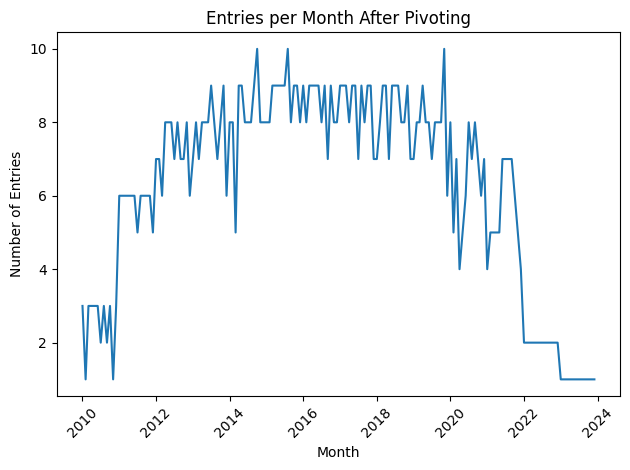

In [16]:
import matplotlib.pyplot as plt

counts = model_df["month"].value_counts().sort_index()

plt.figure()
plt.plot(counts.index, counts.values)
plt.xlabel("Month")
plt.ylabel("Number of Entries")
plt.title("Entries per Month After Pivoting")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
print ("Fraction of missing values per column:")
print (model_df.isna().mean())

Fraction of missing values per column:
location                  0.000000
month                     0.000000
Chloride                  0.127119
Phosphorus                0.285311
Specific conductance      0.191149
Sulfate                   0.122411
Total dissolved solids    0.333333
pH                        0.021657
dtype: float64


We store the final version of our dataset in `data/final` folder.

In [18]:
os.makedirs("data/final", exist_ok=True)
model_df.to_csv("data/final/global_monthly_model_dataset.csv", index=False)

print ("Data shape (rows, columns) after preprocessing:", model_df.shape)

Data shape (rows, columns) after preprocessing: (1062, 8)


### Visualize the Dataset
We create plots with the values over time of top variables (sulfate and phosphorus) for each location.

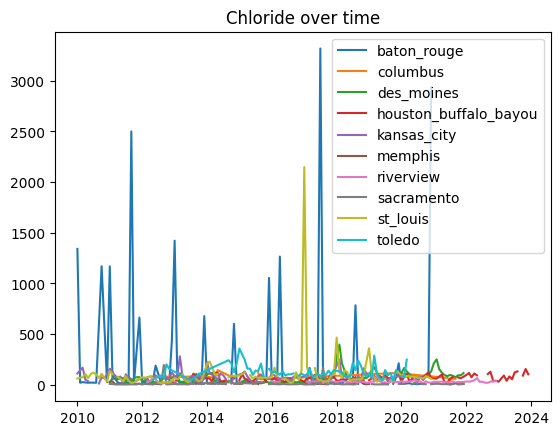

In [19]:
import matplotlib.pyplot as plt

for loc in model_df["location"].unique():
    
    subset = model_df[model_df["location"] == loc]

    plt.plot(subset["month"], subset["Chloride"], label=loc)

plt.legend()
plt.title("Chloride over time")
plt.show()

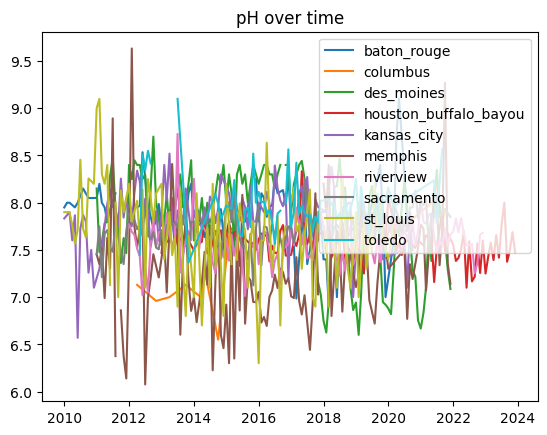

In [20]:
import matplotlib.pyplot as plt

for loc in model_df["location"].unique():
    
    subset = model_df[model_df["location"] == loc]

    plt.plot(subset["month"], subset["pH"], label=loc)

plt.legend()
plt.title("pH over time")
plt.show()

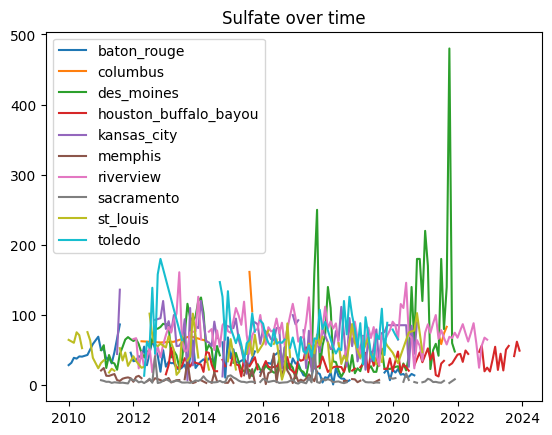

In [21]:
import matplotlib.pyplot as plt

for loc in model_df["location"].unique():
    
    subset = model_df[model_df["location"] == loc]

    plt.plot(subset["month"], subset["Sulfate"], label=loc)

plt.legend()
plt.title("Sulfate over time")
plt.show()

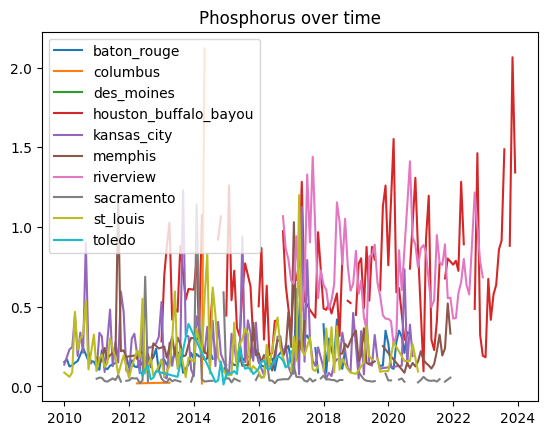

In [22]:
for loc in model_df["location"].unique():
    
    subset = model_df[model_df["location"] == loc]

    plt.plot(subset["month"], subset["Phosphorus"], label=loc)

plt.legend()
plt.title("Phosphorus over time")
plt.show()

## Model Training
We are focusing on sulfate and phosphorus because these two values proved to be the most consistent across the location data and appear to be the best indicators of water quality.

### Generate Feature Colomns
For each model data dataframe, we add lag data and month of year as columns.

In [23]:
model_df = model_df.sort_values(["location", "month"]).copy()
model_df["month"] = pd.to_datetime(model_df["month"])

In [24]:
model_df["month_of_year"] = model_df["month"].dt.month

We create columns for lag sulfate and phosphorus values (last month's measurements) and future target values (3 months into the future).
We choose to shift by 1 month for lag values due to smaller size of our dataset as shifting by 3 removes too much data down the line.

We drop missing values for the lagged features and target variable to create a clean dataset for modeling. This results in a smaller dataset, but ensures that we have complete data for training our models.

In [25]:
def create_lag_and_target_features(df, target_col, lags, target_lag):
    df = df.copy()
    for lag in lags:
        df[f"{target_col}_lag{lag}"] = df.groupby("location")[target_col].shift(lag)
    
    feature_cols = [f"{target_col}_lag{lag}" for lag in lags] + ["month_of_year"]

    target_col_name = f"target_{target_col}"
    df[target_col_name] = df.groupby("location")[target_col].shift(target_lag)

    cols_to_drop_na = feature_cols + [target_col_name]
    model_data = df.dropna(subset=cols_to_drop_na)

    print(f"Shape of the cleaned dataset ({target_col}):", model_data.shape)
    print(f"First few rows of the cleaned dataset ({target_col}):")
    print(model_data[[target_col] + cols_to_drop_na].head())

    return model_data

In [26]:
model_data_sulfate = create_lag_and_target_features(model_df, target_col="Sulfate", lags=[1], target_lag=-3)

Shape of the cleaned dataset (Sulfate): (818, 11)
First few rows of the cleaned dataset (Sulfate):
   Sulfate  Sulfate_lag1  month_of_year  target_Sulfate
1     31.9          28.6              2            41.0
2     39.0          31.9              3            40.7
3     37.9          39.0              4            43.1
4     41.0          37.9              5            58.6
5     40.7          41.0              6            69.1


In [27]:
model_data_phosphorus = create_lag_and_target_features(model_df, target_col="Phosphorus", lags=[1], target_lag=-3)

Shape of the cleaned dataset (Phosphorus): (668, 11)
First few rows of the cleaned dataset (Phosphorus):
   Phosphorus  Phosphorus_lag1  month_of_year  target_Phosphorus
1     0.16800          0.15300              2            0.14775
2     0.12500          0.16800              3            0.15900
3     0.13225          0.12500              4            0.24100
4     0.14775          0.13225              5            0.16000
5     0.15900          0.14775              6            0.15550


In [28]:
model_data_pH = create_lag_and_target_features(model_df, target_col="pH", lags=[1], target_lag=-3)

Shape of the cleaned dataset (pH): (983, 11)
First few rows of the cleaned dataset (pH):
      pH  pH_lag1  month_of_year  target_pH
1  8.000    7.950              2       7.95
2  8.000    8.000              3       8.00
3  7.975    8.000              4       8.15
4  7.950    7.975              5       8.05
5  8.000    7.950              6       8.05


### Split the Data into Training and Testing Data
We apply an 80% train and 20% test data set.

In [29]:
def split_data_into_test_train(model_data, target_col, lags):
    from sklearn.model_selection import train_test_split

    model_data = model_data.reset_index(drop=True)

    feature_cols = [f"{target_col}_lag{lag}" for lag in lags] + ["month_of_year"]

    X = model_data[feature_cols]
    y = model_data[f"target_{target_col}"]
    meta = model_data[["location", "month"]].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    print(f"Shape of the training set ({target_col}):", X_train.shape)
    print(f"Shape of the test set ({target_col}):", X_test.shape)

    return X_train, X_test, y_train, y_test, meta


In [30]:
X_train_sulfate, X_test_sulfate, y_train_sulfate, y_test_sulfate, meta_sulfate = split_data_into_test_train(model_data_sulfate, target_col="Sulfate", lags=[1])

Shape of the training set (Sulfate): (654, 2)
Shape of the test set (Sulfate): (164, 2)


In [31]:
X_train_phosphorus, X_test_phosphorus, y_train_phosphorus, y_test_phosphorus, meta_phosphorus = split_data_into_test_train(model_data_phosphorus, target_col="Phosphorus", lags=[1])

Shape of the training set (Phosphorus): (534, 2)
Shape of the test set (Phosphorus): (134, 2)


In [32]:
X_train_pH, X_test_pH, y_train_pH, y_test_pH, meta_pH = split_data_into_test_train(model_data_pH, target_col="pH", lags=[1])

Shape of the training set (pH): (786, 2)
Shape of the test set (pH): (197, 2)


### Random Forest Regression
Fit the Random Forest Regressor model and generate predictions on train and test data.

In [33]:
def train_model_and_predict(X_train, y_train, X_test, y_test, meta, target_col):
    from sklearn.ensemble import RandomForestRegressor

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results = meta.loc[X_test.index].copy()
    results["actual"] = y_test.values
    results["predicted"] = pred
    print(f"Predictions vs actuals ({target_col}):")
    print(results.head())

    return pred, results

In [34]:
pred_sulfate, results_sulfate = train_model_and_predict(X_train_sulfate, y_train_sulfate, X_test_sulfate, y_test_sulfate, meta_sulfate, target_col="Sulfate")

Predictions vs actuals (Sulfate):
       location      month  actual  predicted
654  sacramento 2018-04-01    2.91   9.208245
655  sacramento 2018-05-01    4.15  30.864137
656  sacramento 2018-07-01    3.28   5.657043
657  sacramento 2018-09-01    7.92   6.800978
658  sacramento 2018-11-01    7.43   6.477866


In [35]:
pred_phosphorus, results_phosphorus = train_model_and_predict(X_train_phosphorus, y_train_phosphorus, X_test_phosphorus, y_test_phosphorus, meta_phosphorus, target_col="Phosphorus")

Predictions vs actuals (Phosphorus):
       location      month    actual  predicted
534  sacramento 2021-07-01  0.030000   0.035494
535  sacramento 2021-08-01  0.055000   0.266028
536    st_louis 2010-03-01  0.229688   0.238289
537    st_louis 2010-04-01  0.301857   0.113540
538    st_louis 2010-05-01  0.327056   0.223744


In [36]:
pred_pH, results_pH = train_model_and_predict(X_train_pH, y_train_pH, X_test_pH, y_test_pH, meta_pH, target_col="pH")

Predictions vs actuals (pH):
       location      month    actual  predicted
786  sacramento 2018-05-01  7.787500   7.662856
787  sacramento 2018-06-01  7.575000   7.676923
788  sacramento 2018-07-01  7.809091   7.688374
789  sacramento 2018-08-01  7.900000   7.630431
790  sacramento 2018-09-01  7.790000   7.644167


### Evaluate the predictions
We evaluate the predictions with MAE, RMSE, and R^2.

In [37]:
def evaluate_predictions(y_test, pred, target_col):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    import numpy as np

    mae = mean_absolute_error(y_test, pred)
    mse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f"Evaluation metrics for {target_col}:")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"R^2 Score: {r2:.4f}")

In [38]:
evaluate_predictions(y_test_sulfate, pred_sulfate, target_col="Sulfate")

Evaluation metrics for Sulfate:
Mean Absolute Error: 20.0809
Mean Squared Error: 30.7924
R^2 Score: 0.1019


In [39]:
evaluate_predictions(y_test_phosphorus, pred_phosphorus, target_col="Phosphorus")

Evaluation metrics for Phosphorus:
Mean Absolute Error: 0.1696
Mean Squared Error: 0.2356
R^2 Score: -2.1258


In [40]:
evaluate_predictions(y_test_pH, pred_pH, target_col="pH")

Evaluation metrics for pH:
Mean Absolute Error: 0.3386
Mean Squared Error: 0.4578
R^2 Score: -0.2453


### Define Risk Thresholds and Risk Scores
Based on real-world regulations, the **sulfate threshold** is approximately 250 mg/l, and the **phosphorus threshold** is approximately 0.1 mg/l.

**Risk score** is calculated as the predicted chemical level divided by the threshold. A score of 1 means the predicted level is at the threshold, above 1 is high risk, and below 1 is lower risk.

For pH, risk score equals 0 if predicted pH is between 6.5 and 8.5 (optimal pH range for most living organisms). It is normalized by dividing the distance from the nearest threshold (6.5 or 8.5) by that threshold, so it represents the relative deviation from the ideal range.
 
Sources:

https://www.epa.gov/system/files/documents/2023-04/draftma0101711permit.pdf

https://www.epa.gov/sdwa/drinking-water-regulations-and-contaminants

https://www.epa.gov/national-aquatic-resource-surveys/indicators-acidification


In [41]:
def determine_risk_score_and_level (results, threshold, target_col):
    results["risk_score"] = results["predicted"] / threshold

    def risk_level(score):
        if score >= 1.0:
            return "High"
        elif score >= 0.8:
            return "Medium"
        else:
            return "Low"

    results["risk_level"] = results["risk_score"].apply(risk_level)

    print(f"{target_col} results with risk levels:")
    print(results.head())

    return results

In [42]:
sulfate_threshold = 250

results_sulfate = determine_risk_score_and_level(results_sulfate, threshold=sulfate_threshold, target_col="Sulfate")

Sulfate results with risk levels:
       location      month  actual  predicted  risk_score risk_level
654  sacramento 2018-04-01    2.91   9.208245    0.036833        Low
655  sacramento 2018-05-01    4.15  30.864137    0.123457        Low
656  sacramento 2018-07-01    3.28   5.657043    0.022628        Low
657  sacramento 2018-09-01    7.92   6.800978    0.027204        Low
658  sacramento 2018-11-01    7.43   6.477866    0.025911        Low


In [43]:
phosphorus_threshold = 0.1

results_phosphorus = determine_risk_score_and_level(results_phosphorus, threshold=phosphorus_threshold, target_col="Phosphorus")

Phosphorus results with risk levels:
       location      month    actual  predicted  risk_score risk_level
534  sacramento 2021-07-01  0.030000   0.035494    0.354936        Low
535  sacramento 2021-08-01  0.055000   0.266028    2.660284       High
536    st_louis 2010-03-01  0.229688   0.238289    2.382892       High
537    st_louis 2010-04-01  0.301857   0.113540    1.135399       High
538    st_louis 2010-05-01  0.327056   0.223744    2.237443       High


In [ ]:
def determine_risk_score_and_level_pH(results):

    def risk_score(row):
        if row["predicted"] > 6.5 and row["predicted"] < 8.5:
            return 0
        elif row["predicted"] <= 6.5:
            return (6.5 - row["predicted"]) / 6.5
        elif row["predicted"] >= 8.5:
            return (row["predicted"] - 8.5) / 8.5
        else:
            return None

    results["risk_score"] = results.apply(risk_score, axis=1)

    def risk_level(score):
        if score >= 0.5:
            return "High"
        elif score >= 0:
            return "Medium"
        else:
            return "Low"

    results["risk_level"] = results["risk_score"].apply(risk_level)

    print(f"pH results with risk levels:")
    print(results.head())

    return results

In [45]:
results_pH = determine_risk_score_and_level_pH(results_pH)

pH results with risk levels:
       location      month    actual  predicted  risk_score risk_level
786  sacramento 2018-05-01  7.787500   7.662856           0     Medium
787  sacramento 2018-06-01  7.575000   7.676923           0     Medium
788  sacramento 2018-07-01  7.809091   7.688374           0     Medium
789  sacramento 2018-08-01  7.900000   7.630431           0     Medium
790  sacramento 2018-09-01  7.790000   7.644167           0     Medium


In [46]:
def risk_summary_by_location(results, target_col):
    summary = (
        results.groupby("location")["risk_score"]
        .max()
        .reset_index()
        .sort_values("risk_score", ascending=False)
    )

    print(f"Risk summary by location for {target_col}:")
    print(summary)

    return summary

In [47]:
risk_summary_sulfate = risk_summary_by_location(results_sulfate, target_col="Sulfate")

Risk summary by location for Sulfate:
     location  risk_score
1    st_louis    0.766861
2      toledo    0.499720
0  sacramento    0.151328


In [48]:
risk_summary_phosphorus = risk_summary_by_location(results_phosphorus, target_col="Phosphorus")

Risk summary by location for Phosphorus:
     location  risk_score
1    st_louis    9.818011
2      toledo    9.396481
0  sacramento    2.660284


In [49]:
risk_summary_pH = risk_summary_by_location(results_pH, target_col="pH")

Risk summary by location for pH:
     location  risk_score
0  sacramento           0
1    st_louis           0
2      toledo           0


### Plot and Visualize the Predictions

In [50]:
def plot_predictions_vs_actuals(results, target_col, unit=""):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12,6))

    plt.plot(
        results["actual"].values[:120],
        label=f"Actual {target_col}",
        linewidth=2
    )

    plt.plot(
        results["predicted"].values[:120],
        label=f"Predicted {target_col} (3-month forecast)",
        linewidth=2
    )

    plt.title(f"3-Month {target_col} Forecast vs Actual")
    plt.xlabel("Test Observations")
    plt.ylabel(f"{target_col} ({unit})")
    plt.legend()
    plt.show()

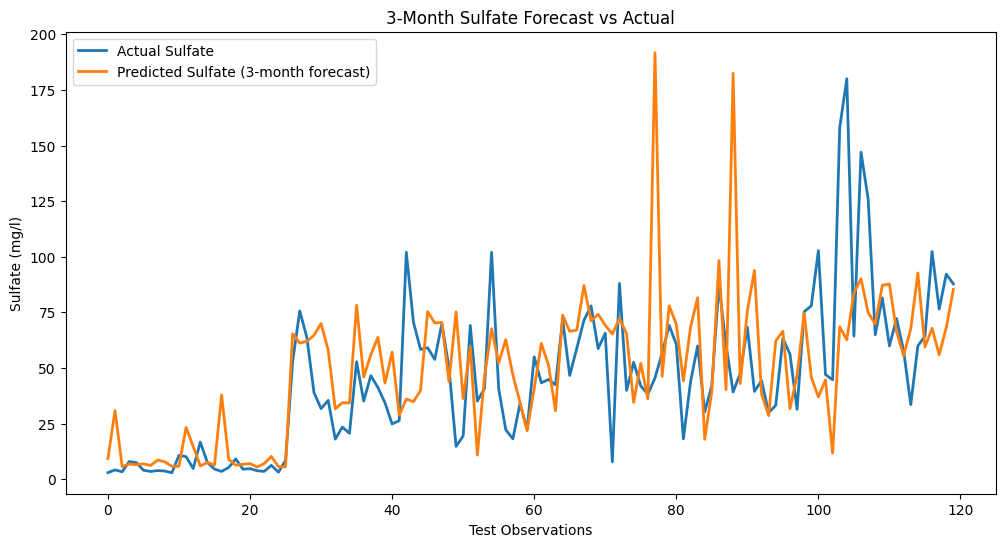

In [51]:
plot_predictions_vs_actuals(results_sulfate, target_col="Sulfate", unit="mg/l")

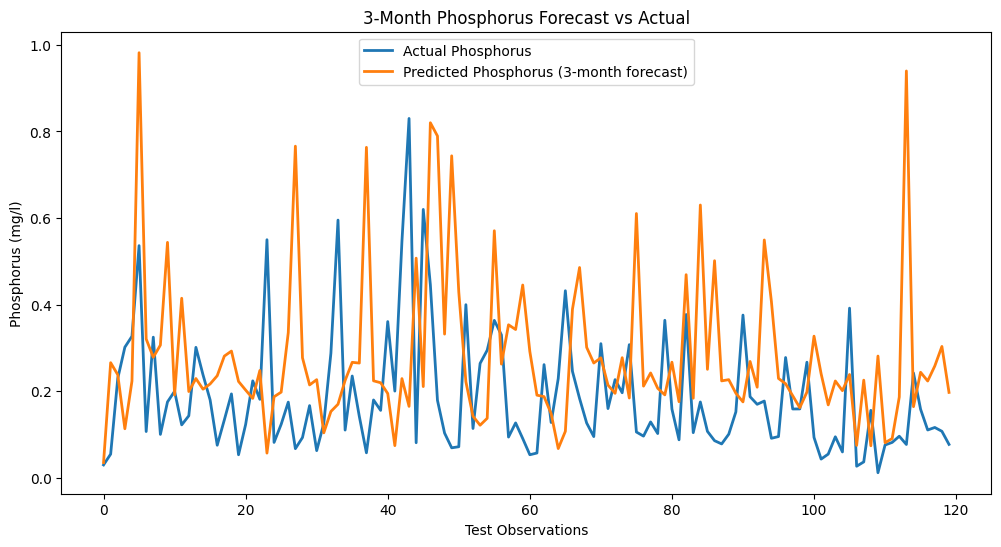

In [52]:
plot_predictions_vs_actuals(results_phosphorus, target_col="Phosphorus", unit="mg/l")

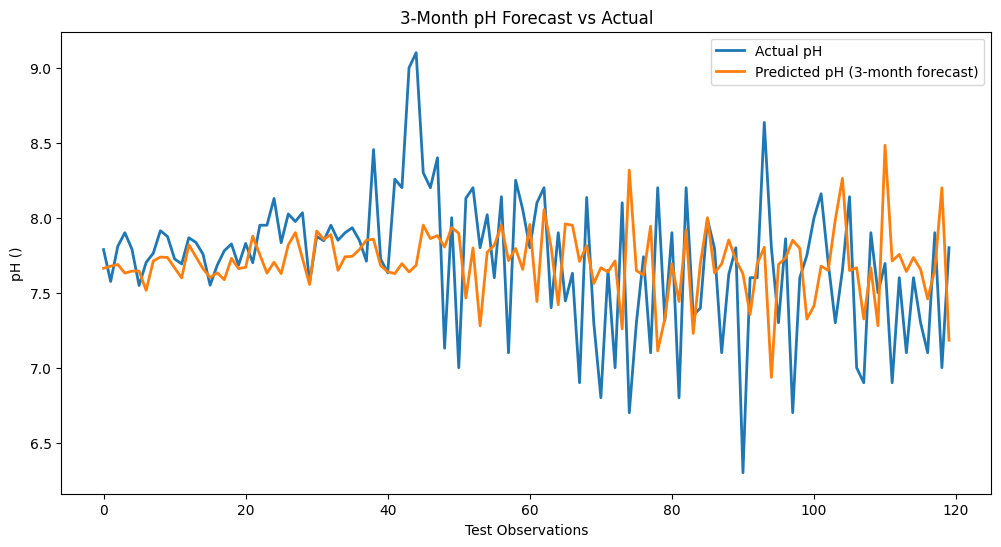

In [53]:
plot_predictions_vs_actuals(results_pH, target_col="pH")

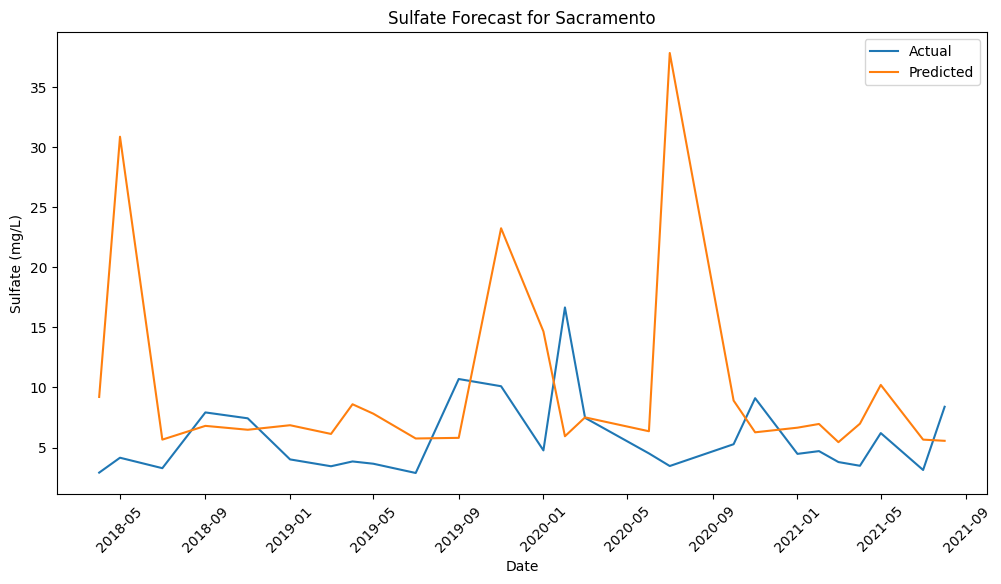

In [54]:
loc = "sacramento"

subset = results_sulfate[results_sulfate["location"] == loc]

plt.figure(figsize=(12,6))

plt.plot(subset["month"], subset["actual"], label="Actual")
plt.plot(subset["month"], subset["predicted"], label="Predicted")

plt.title(f"Sulfate Forecast for Sacramento")
plt.ylabel("Sulfate (mg/L)")
plt.xlabel("Date")
plt.legend()

plt.xticks(rotation=45)
plt.show()

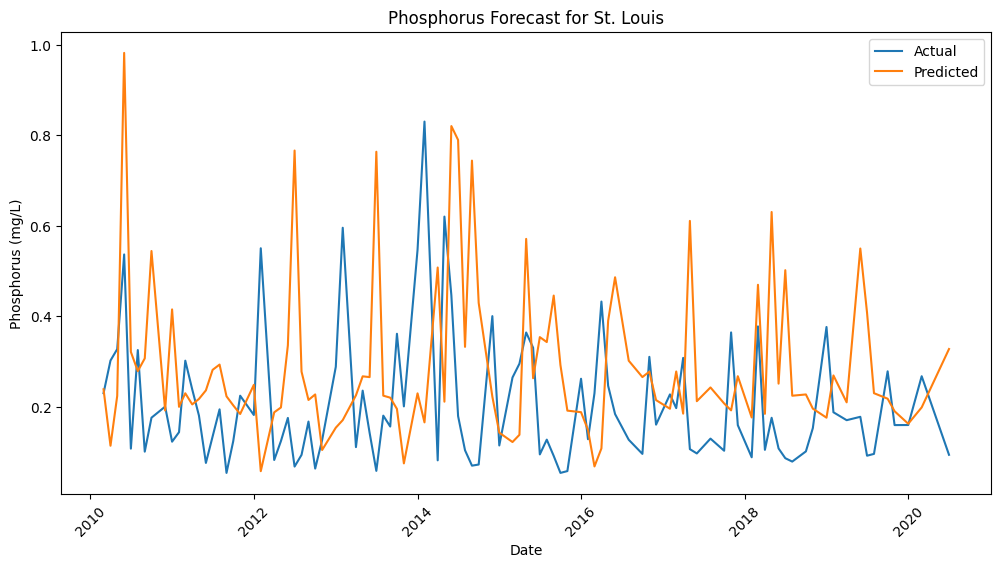

In [55]:
loc1 = "st_louis"

subset1 = results_phosphorus[results_phosphorus["location"] == loc1]

plt.figure(figsize=(12,6))

plt.plot(subset1["month"], subset1["actual"], label="Actual")
plt.plot(subset1["month"], subset1["predicted"], label="Predicted")

plt.title(f"Phosphorus Forecast for St. Louis")
plt.ylabel("Phosphorus (mg/L)")
plt.xlabel("Date")
plt.legend()

plt.xticks(rotation=45)
plt.show()

## Store the Results Output
We locally store the CSV files with predictions and risk scores. We plan to integrate S3 in the future.

In [56]:
import os
os.makedirs("data/final", exist_ok=True)

results_sulfate.to_csv("data/final/sulfate_predictions.csv", index=False)
risk_summary_sulfate.to_csv("data/final/sulfate_location_risk_summary.csv", index=False)

results_phosphorus.to_csv("data/final/phosphorus_predictions.csv", index=False)
risk_summary_phosphorus.to_csv("data/final/phosphorus_location_risk_summary.csv", index=False)

results_pH.to_csv("data/final/pH_predictions.csv", index=False)
risk_summary_pH.to_csv("data/final/pH_location_risk_summary.csv", index=False)